In [107]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import colorsys
import matplotlib.pyplot as plt
import os,sys
from pathlib import Path

# NOTE: My .py files
from standardizing_data import (
    standardize_lc,normalize_standardized_lc,_apply_quality_mask,
    get_tess_lc,
    _get_colors,
    collect_lightcurves_for_target,
    # constants
    DEFAULT_RADIUS,
    DEFAULT_CADENCE,
    DEFAULT_DOWNLOADPATH
)


from phasefold import phasefold, plot_phasefolded
from astropy.stats import sigma_clip

# Read in catalog data

In [108]:
catalog_dir = (Path.cwd() / "../Catalog/").resolve()

nearby_TOI_MD_df_ORIG=pd.read_csv(f'{catalog_dir}/nearby_TOI_MDs.csv')
nearby_TOI_MD_df_ORIG.head(5)

,Unnamed: 0,Parameter Source Pipeline,Detection Pipeline(s),TIC ID,Full TOI ID,TOI Disposition,TIC Right Ascension,TIC Declination,TIC Right Ascension 2015.5,TIC Declination 2015.5,TMag Value,TMag Uncertainty,Orbital Epoch Value,Epoch Uncertainty,Orbital Period (days) Value,Orbital Period Uncertainty,Transit Duration (hours) Value,Transit Duration (hours) Uncertainty,Transit Depth Value,Transit Depth Uncertainty,Sectors,Public Comment,Surface Gravity Value,Surface Gravity Uncertainty,Planet Number,Star Radius Value,Star Radius Uncertainty,Planet Radius Value,Planet Radius Uncertainty,Planet Equilibrium Temperature (K) Value,Effective Temperature Value,Effective Temperature Uncertainty,Effective Stellar Flux Value,Signal-to-noise,Centroid Offset,Master,SG1a,SG1b,SG2,SG3,SG4,SG5,Alerted,Updated,ID,ra,dec,pmRA,pmDEC,Tmag,objType,typeSrc,version,HIP,TYC,UCAC,TWOMASS,SDSS,ALLWISE,GAIA,APASS,KIC,POSflag,e_pmRA,e_pmDEC,PMflag,plx,e_plx,PARflag,gallong,gallat,eclong,eclat,Bmag,e_Bmag,Vmag,e_Vmag,umag,e_umag,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,e_zmag,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag,TWOMflag,prox,w1mag,e_w1mag,w2mag,e_w2mag,w3mag,e_w3mag,w4mag,e_w4mag,GAIAmag,e_GAIAmag,e_Tmag,TESSflag,SPFlag,Teff,e_Teff,logg,e_logg,MH,e_MH,rad,e_rad,mass,e_mass,rho,e_rho,lumclass,lum,e_lum,d,e_d,ebv,e_ebv,numcont,contratio,disposition,duplicate_id,priority,eneg_EBV,epos_EBV,EBVflag,eneg_Mass,epos_Mass,eneg_Rad,epos_Rad,eneg_rho,epos_rho,eneg_logg,epos_logg,eneg_lum,epos_lum,eneg_dist,epos_dist,distflag,eneg_Teff,epos_Teff,TeffFlag,gaiabp,e_gaiabp,gaiarp,e_gaiarp,gaiaqflag,starchareFlag,VmagFlag,BmagFlag,splists,e_RA,e_Dec,RA_orig,Dec_orig,e_RA_orig,e_Dec_orig,raddflag,wdflag,dstArcSec,qld_a,qld_b,i,M_planet [ME],K_RV [m/s],TSM,ESM,Stellar Insolation [ergs/cm^2/s],Stellar Insolation [Earth Units],Sectors_Observed,Cameras,CCDs,EdgeWarn
0,0,spoc-s01-s36-b0A-CPKP,SPOC,410153553,136.01,PC,340.492100,-69.169000,340.496204,-69.172108,11.877,0.064,1325.724661,0.000156,0.462931,3.872269e-06,0.631015,0.022202,4677.673602,171.681260,"1,27,28,67,68,94,95,101,102,103,104",LHS 3844 b,5.09707,0.426694,1,0.188624,0.005710,1.517197,0.061800,723.372047,3043.0,63.0,64.709477,38.885654,False,5,5,5,5,5,5,5,2018-09-05 18:51:57+00:00,2020-10-27 13:01:47.547000+00:00,410153553,340.492156,-69.168978,334.3570,-726.9740,11.92380,STAR,tmgaia2,20190415,NaN,NaN,105-116381,22415815-6910089,NaN,NaN,6385548541499112448,33464847.0,NaN,tmgaia2,0.082820,0.086335,gaia2,67.15480,0.050599,gaia2,318.253844,-43.907555,304.887051,-54.122569,16.942,0.041,15.240,0.032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.046,0.023,9.477,0.023,9.145,0.023,AAA-222-111-000-0-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.3925,0.000738,0.007698,cdwrf,cdwrf,3004.0,157.0,5.08528,0.029186,NaN,NaN,0.188624,0.005710,0.157909,0.020067,23.52970,0.863072,DWARF,0.002610,0.000708,14.8846,0.0113,0.000000,0.000000,81.0,0.010833,NaN,NaN,0.009687,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0113,0.0113,bj2018,NaN,NaN,cdwrf,15.4512,0.007263,12.05170,0.002827,1,NaN,cdwrf,apassdr9,cooldwarfs_v8,1.559812,1.338867,340.496204,-69.172108,0.041207,0.042399,1,0,0.0,0.1933,0.5347,1.570796,2.913518,8.243782,328.631928,NaN,8.866874e+07,64.915025,11.0,"3,3,3,2,2,2,2,4,4,3,3","2,1,2,2,1,2,1,3,2,3,2","0,0,0,0,0,0,0,0,0,0,0"
1,1,spoc-s01-s69-b0A-CP,SPOC/QLP,234994474,134.01,CP,350.031300,-60.065200,350.028592,-60.065729,9.169,0.019,1326.034032,0.000566,1.401518,4.810232e-06,1.158306,0.325507,593.754092,42.808456,"1,28,68,95,102,104,105",L 168-9 b,4.67812,0.063226,1,0.597007,0.018150,1.461685,1.838503,891.638989,3794.0,69.0,149.374754,20.450527,False,5,5,5,5,5,5,5,2018-09-05 18:51:57+00:00,2024-09-30 23:32:46.016000+00:00,234994474,350.031352,-60.065179,-319.9610,-127.7810,9.22978,STAR,tmgaia2,20190415,115211.0,9126-00748-1,150-224713,23200751-6003545,NaN,NaN,6491962296196145664,31785853.0,NaN,tmgaia2,0.102122,0.115073,gaia2,39.73310,0.037526,gaia2,321.954596,-53.560374,319.217901,-49.527946,12.460,0.025,11.005,0.018,Na

# Filter for targets that are more likely to be detectable across pipelines:

In [109]:
df = nearby_TOI_MD_df_ORIG.copy()

mask = (
#     (df["Signal-to-noise"] >= 10) &
    (df["Transit Depth Value"]/1e6 >= 1000/1e6) &
    (df["Transit Duration (hours) Value"] >= 0.75) &
#     (df["Transit Duration (hours) Value"] <= 10.0) &
    (df["Sectors_Observed"] >= 2) &
    (df["Centroid Offset"].isna() | (df["Centroid Offset"] == 0)) &
    (df["TOI Disposition"].isin(["PC", "KP", "CP"])) &
    (df["contratio"] <= 0.1) &
#     (df["Tmag"] >= 7) & (df["Tmag"] <= 13.5) &
    (df["Orbital Period (days) Value"] >= 0.5) #&
#     (df["Orbital Period (days) Value"] <= 13.0) &
#     (df["EdgeWarn"].isna() | (df["EdgeWarn"] == 0))
)
filtered_df = df[mask].copy()
print(f"{mask.sum()} / {len(df)} targets pass ({100*mask.mean():.1f}%)")



nearby_TOI_MD_df = filtered_df

225 / 471 targets pass (47.8%)


[compile_filtered] WARNING: 49 TIC IDs in filtered_df have no corresponding parquet:
  103605399, 126982221, 143032776, 150096001, 16005254, 165202476, 16550540, 173103335, 19028197, 203214081...
[compile_filtered] Loaded 565 rows across 160 parquets (154 unique TICs, 49 not found on disk).
Catalog: 565 rows, 154 targets
classification
FA    399
PC    137
FP     29
Name: count, dtype: int64
pipeline  NEMESIS  QLP TESS-SPOC TGLC GSFC-ELEANOR-LITE consensus  n_agree  \
ID                                                                           
120916706      FA  NaN        PC   PC                PC       PC*        3   
126606859      FA   FA        PC  NaN               NaN       FA*        2   
138819293      FA   PC        FA  NaN               NaN       FA*        2   
141527579      FP   PC        PC   FP                FA       FP*        2   
141608198      FA   PC        PC   PC                FP       PC*        3   
150428135      FA   PC        PC   FP                FA     

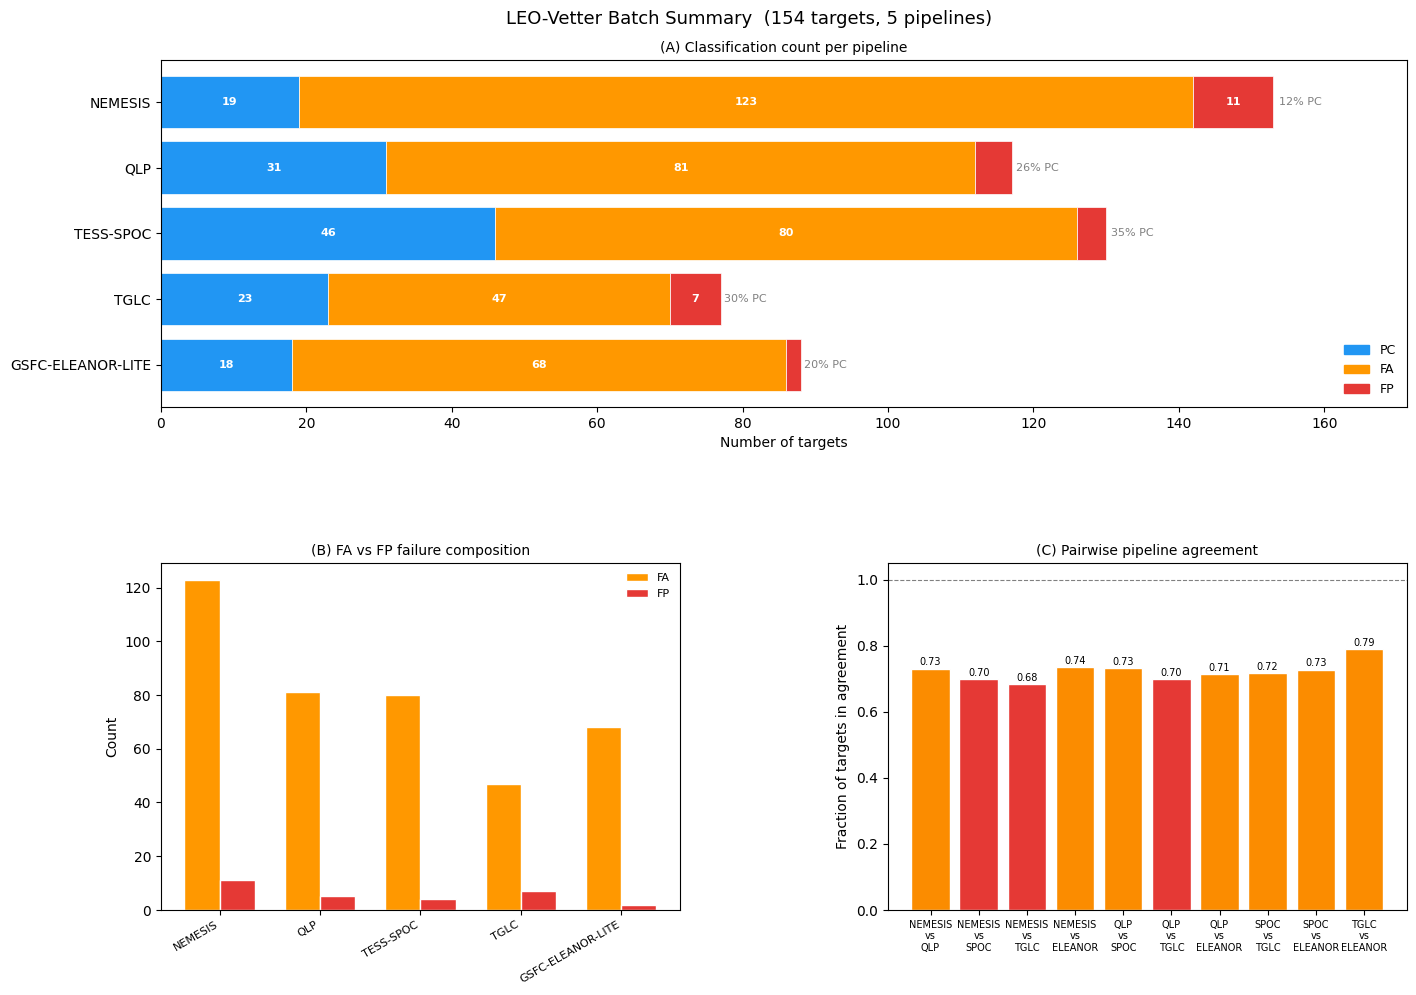

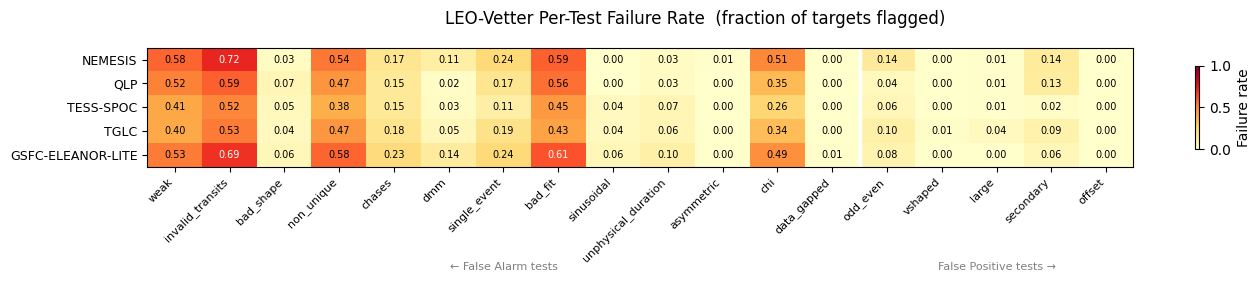

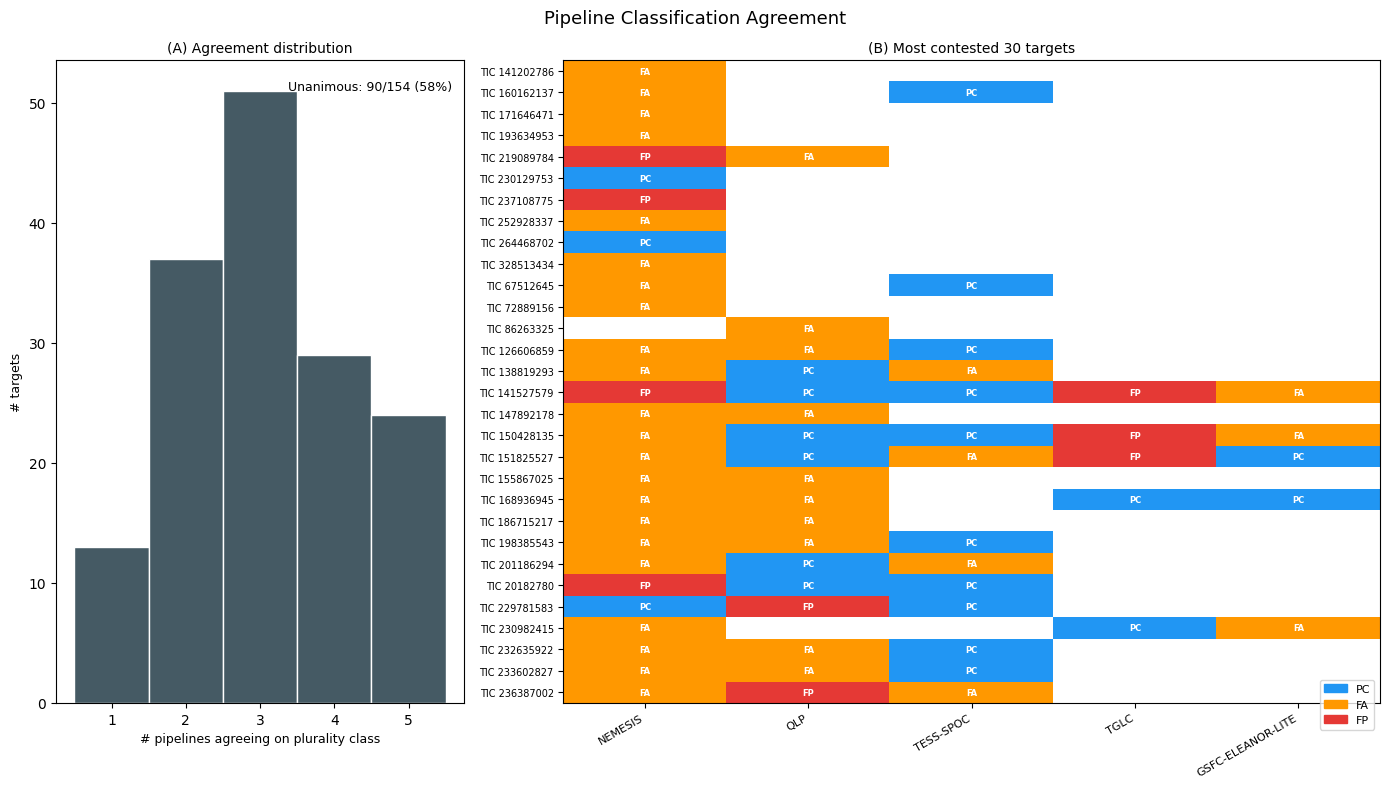

In [110]:


from leovetter_batch_analysis import (compile_batch_leovetter_catalog, 
                                      compile_batch_leovetter_catalog_filtered,
                                      add_per_test_flags,
                                      derive_classification,
                                      classification_agreement_table,
                                      plot_population_summary,
                                      plot_flag_rate_heatmap,
                                     plot_pipeline_agreement)
from standardizing_data import (
    DEFAULT_DOWNLOADPATH, )
RESULTS_ROOT  = os.path.join(DEFAULT_DOWNLOADPATH, "batch_results")

# ─────────────────────────────────────────────────────────────────────────────
# Example usage
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    # 1. Compile
#     cat = compile_batch_leovetter_catalog(RESULTS_ROOT)
    cat = compile_batch_leovetter_catalog_filtered(results_root=RESULTS_ROOT, 
                                                   filtered_df=filtered_df)

    # 2. Derive per-test boolean flags from stored metrics
    # chi_threshold: raise above canonical 2.0 for active M-dwarfs.
    # Calibrate empirically; 7.0 is a reasonable starting point.
    cat = add_per_test_flags(cat, chi_threshold=7.0)

    # 3. Classify
    cat = derive_classification(cat)

    print(f"Catalog: {len(cat)} rows, {cat['ID'].nunique()} targets")
    print(cat["classification"].value_counts())

    # 4. Agreement table (for paper / supplement)
    tbl = classification_agreement_table(cat)
    print(tbl[tbl["consensus"].str.endswith("*")])  # contested targets only

    # 5. Figures
    fig1 = plot_population_summary(
        cat, savepath=os.path.join(RESULTS_ROOT, "fig_population_summary.png"))

    fig2 = plot_flag_rate_heatmap(
        cat, savepath=os.path.join(RESULTS_ROOT, "fig_flag_rate_heatmap.png"))

    fig3 = plot_pipeline_agreement(
        cat, top_n_contested=30,
        savepath=os.path.join(RESULTS_ROOT, "fig_pipeline_agreement.png"))

    plt.show()

# Show full distribution of all LEO-Vetter metrics

[compile_filtered] WARNING: 49 TIC IDs in filtered_df have no corresponding parquet:
  103605399, 126982221, 143032776, 150096001, 16005254, 165202476, 16550540, 173103335, 19028197, 203214081...
[compile_filtered] Loaded 565 rows across 160 parquets (154 unique TICs, 49 not found on disk).
Saved: /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/batch_results/saved_results/fig_metric_distributions.png


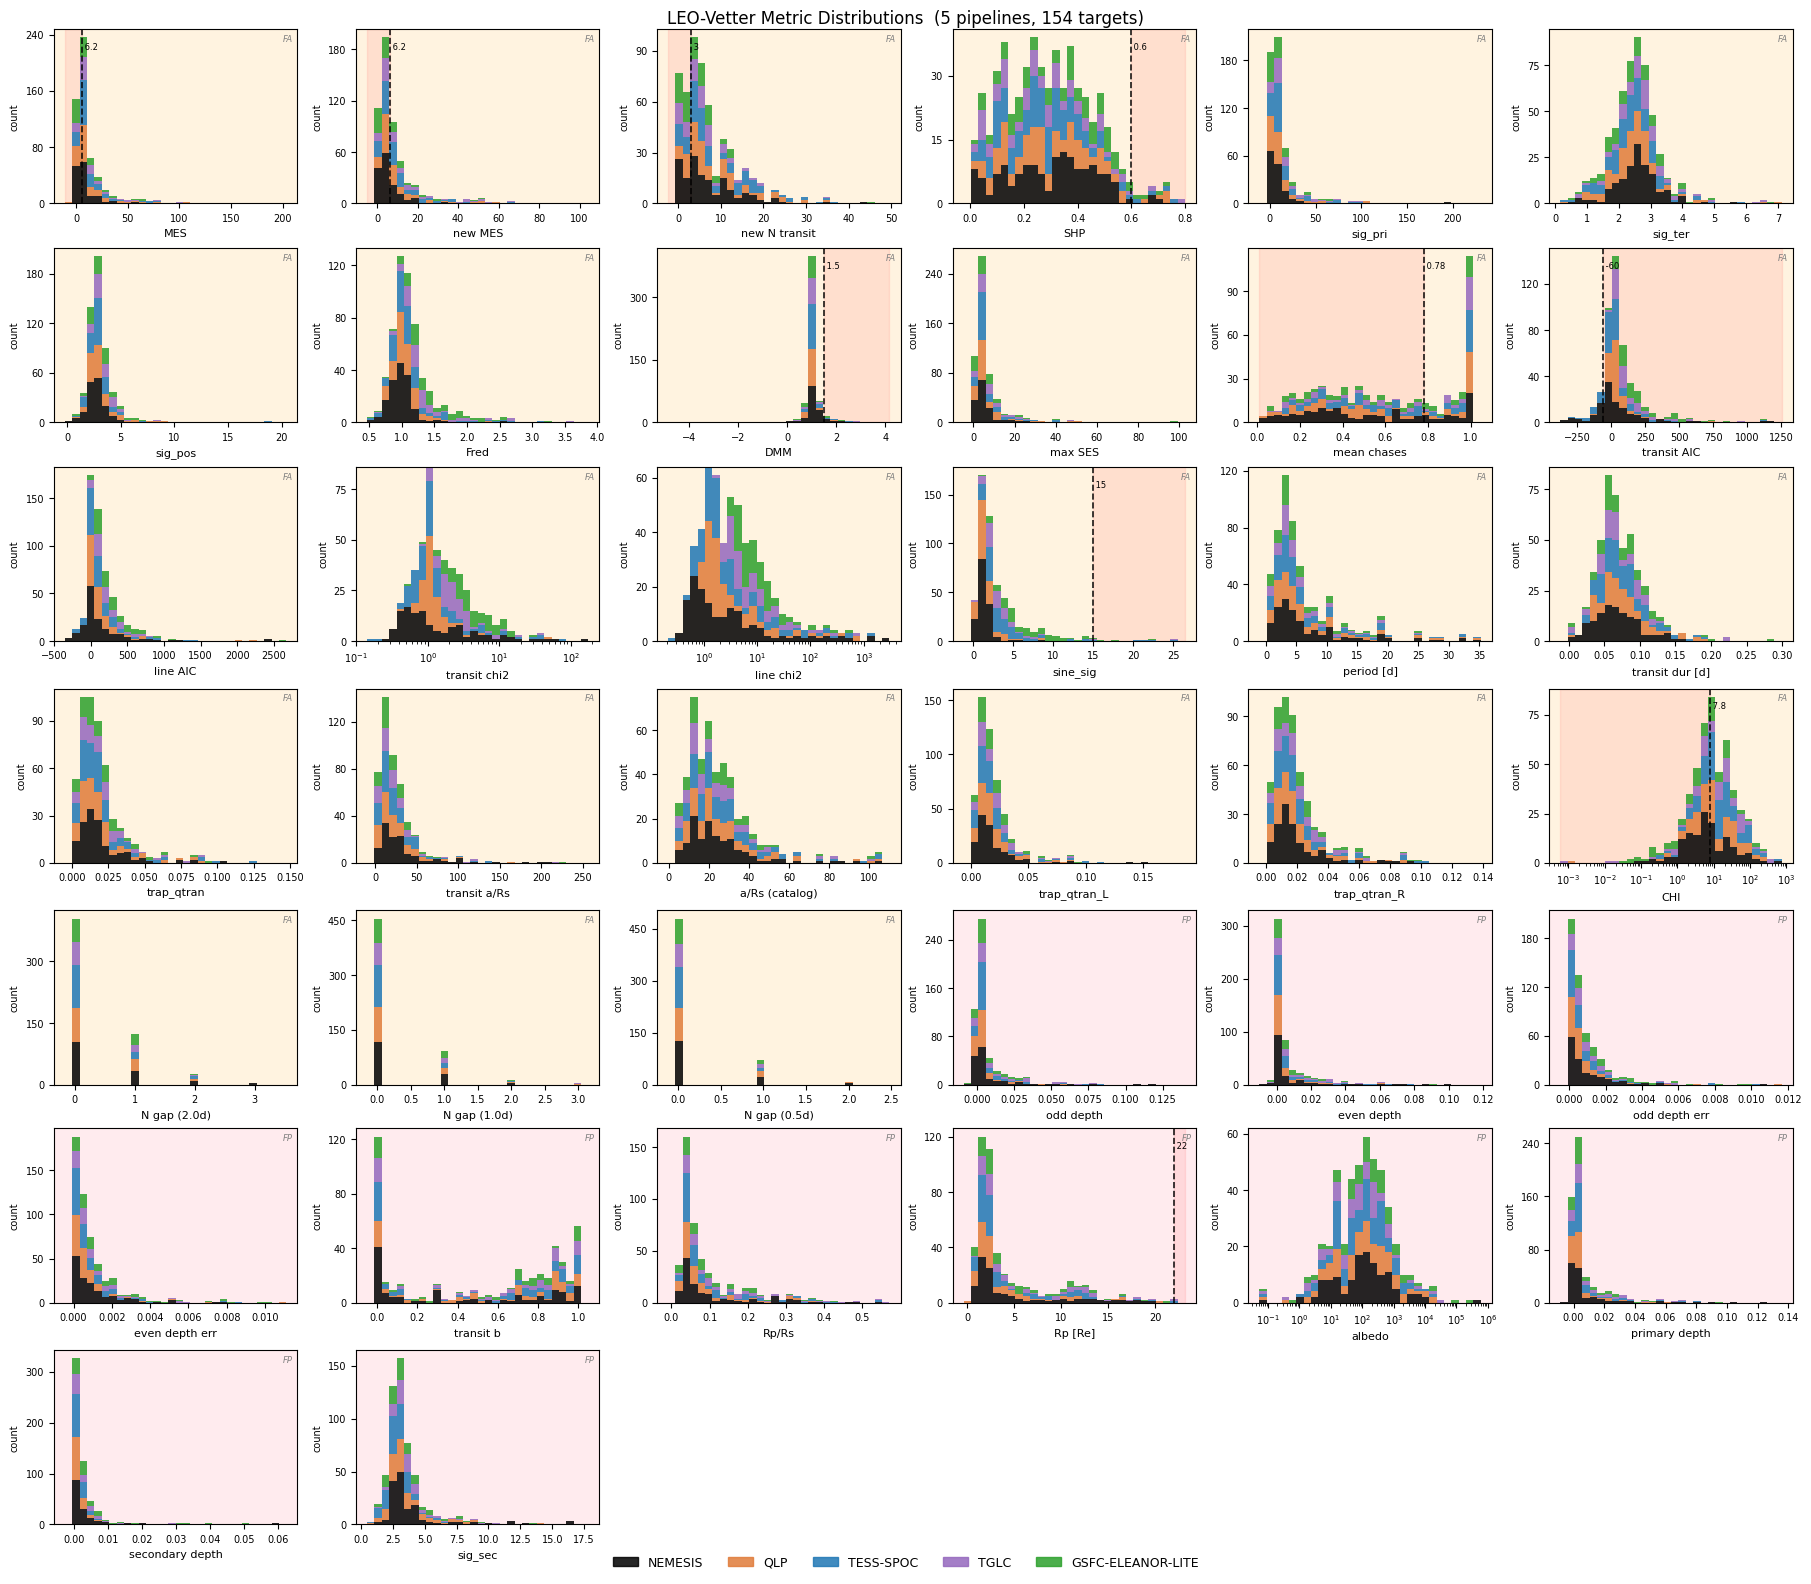

Saved: /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/batch_results/saved_results/fig_metric_distributions_full.png


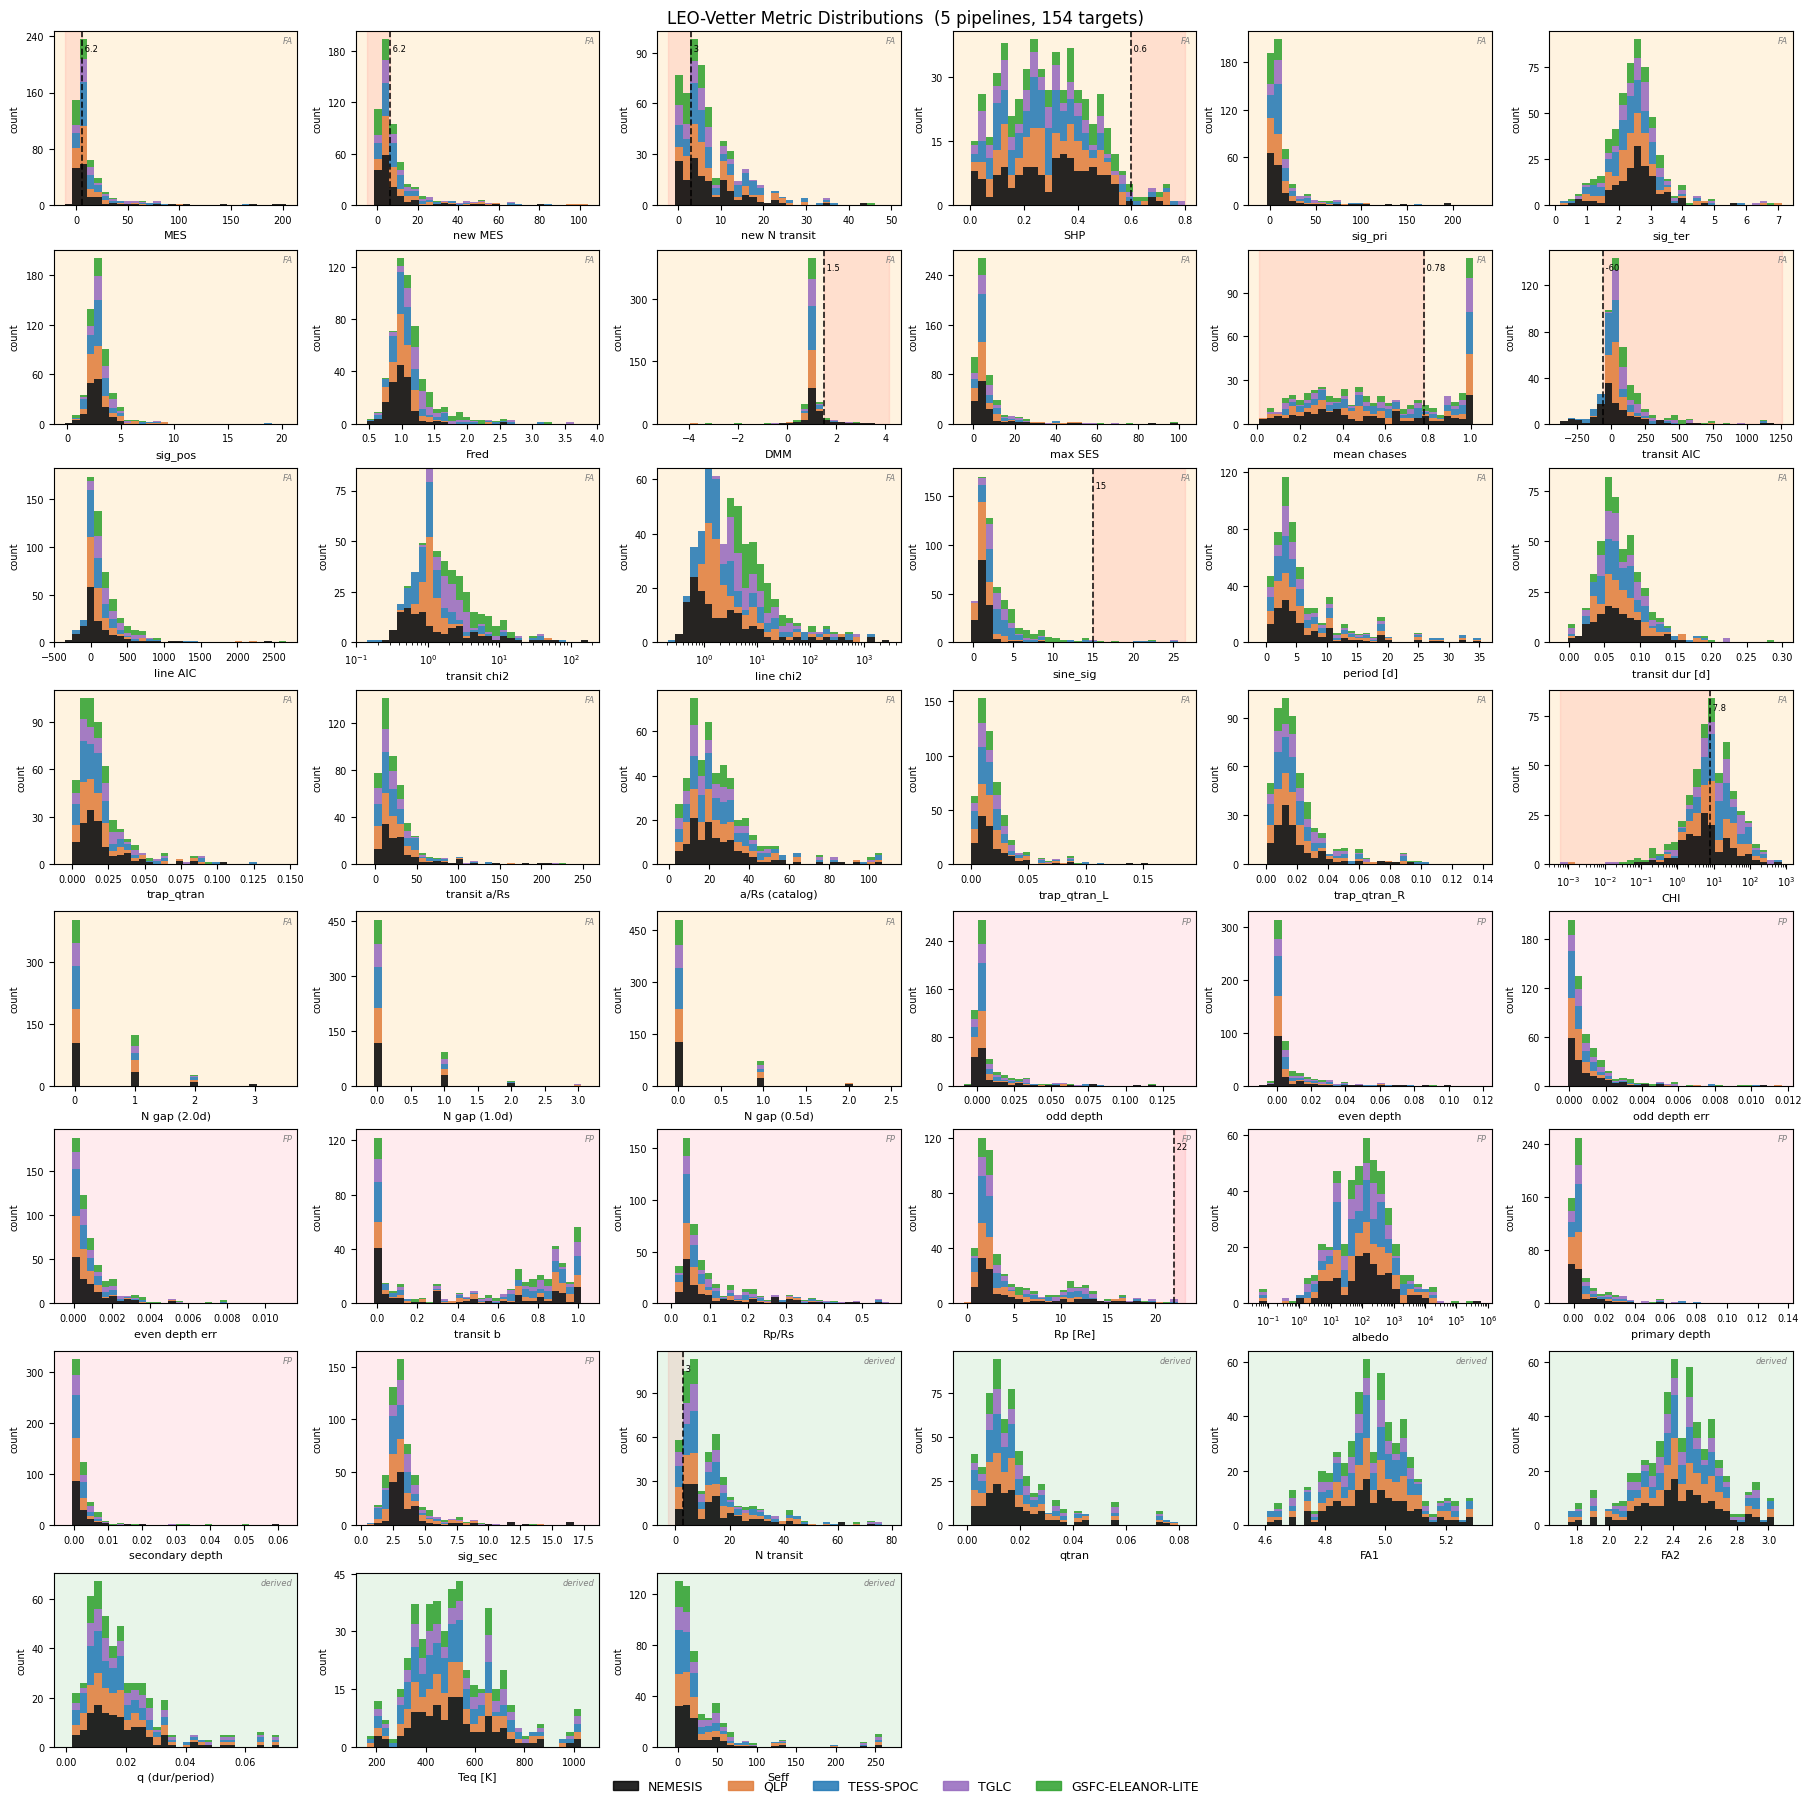

In [111]:
# ─────────────────────────────────────────────────────────────────────────────
# Example usage
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import os
    from leovetter_batch_analysis import compile_batch_leovetter_catalog, plot_leovetter_metric_distributions

    RESULTS_ROOT = "/Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/batch_results/saved_results/"

#     cat = compile_batch_leovetter_catalog(RESULTS_ROOT)
    cat = compile_batch_leovetter_catalog_filtered(results_root=RESULTS_ROOT, 
                                                   filtered_df=filtered_df)

    # Primary figure: FA + FP metrics, CHI threshold at canonical 7.8
    fig = plot_leovetter_metric_distributions(
        cat,
        chi_threshold=None,   # use _default_thresholds["CHI"] = 7.8
        n_cols=6,
        savepath=os.path.join(RESULTS_ROOT, "fig_metric_distributions.png"),
    )
    plt.show()

    # Full audit including derived quantities
    fig2 = plot_leovetter_metric_distributions(
        cat,
        chi_threshold=None,
        show_derived_metrics=True,
        n_cols=6,
        savepath=os.path.join(RESULTS_ROOT, "fig_metric_distributions_full.png"),
    )
    plt.show()

#

# Some tests seem to be failing more than others: weak, invalid_transits, bad_shape, non-uniqueness, and chi.

# This is likely due to how each pipelien extracts photometry and then processes it. For M-dwarfs, stellar activity may be more of a factor than these pipeline's abilities to process TESS data in general. If we exclude these tests, we may get a more comparable yield of "PC" dispositions among pipelines

[compile_filtered] WARNING: 49 TIC IDs in filtered_df have no corresponding parquet:
  103605399, 126982221, 143032776, 150096001, 16005254, 165202476, 16550540, 173103335, 19028197, 203214081...
[compile_filtered] Loaded 565 rows across 160 parquets (154 unique TICs, 49 not found on disk).
Catalog: 565 rows, 154 targets, 5 pipelines

Full classification counts (all pipelines combined):
classification
FA    404
PC    133
FP     28
Name: count, dtype: int64

Full classification counts per pipeline:
classification      FA  FP  PC
pipeline                      
GSFC-ELEANOR-LITE   69   2  17
NEMESIS            125  10  18
QLP                 82   5  30
TESS-SPOC           80   4  46
TGLC                48   7  22
[agnostic classification] excluded tests: ['chi', 'sinusoidal', 'non_unique', 'invalid_transits', 'bad_fit', 'weak']
  FA tests retained: ['bad_shape', 'chases', 'dmm', 'single_event', 'unphysical_duration', 'asymmetric', 'data_gapped']
  FP tests retained: ['odd_even', 'vshaped'

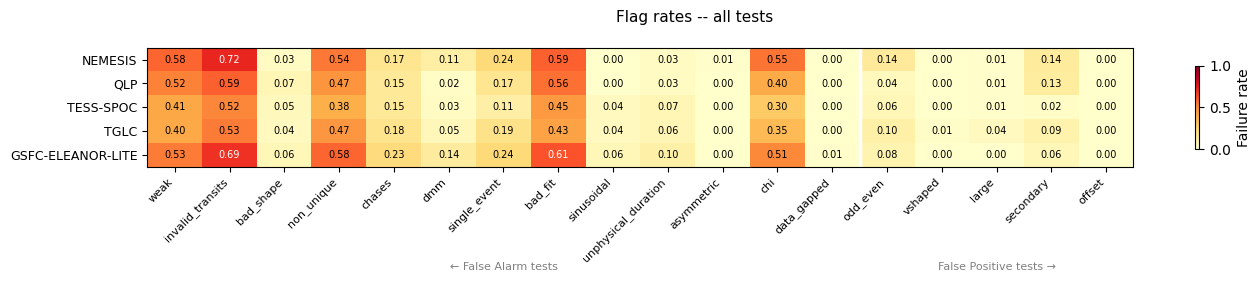

Saved: /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/batch_results/saved_results/figures/flag_rate_heatmap_agnostic.png


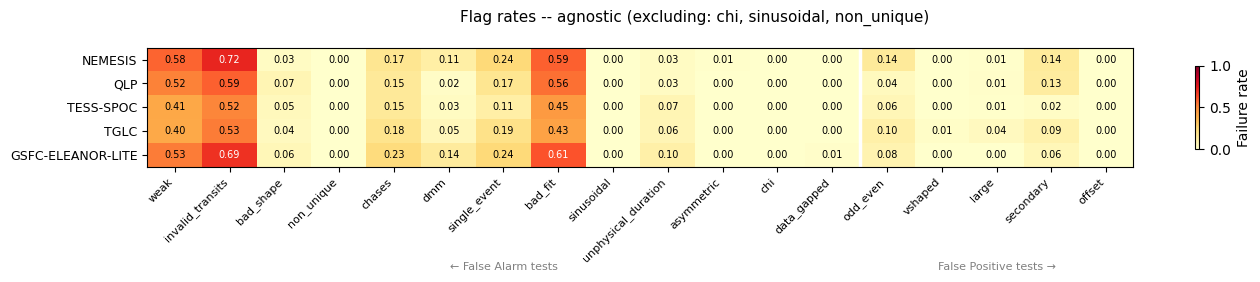

Saved: /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/batch_results/saved_results/figures/population_summary_full.png


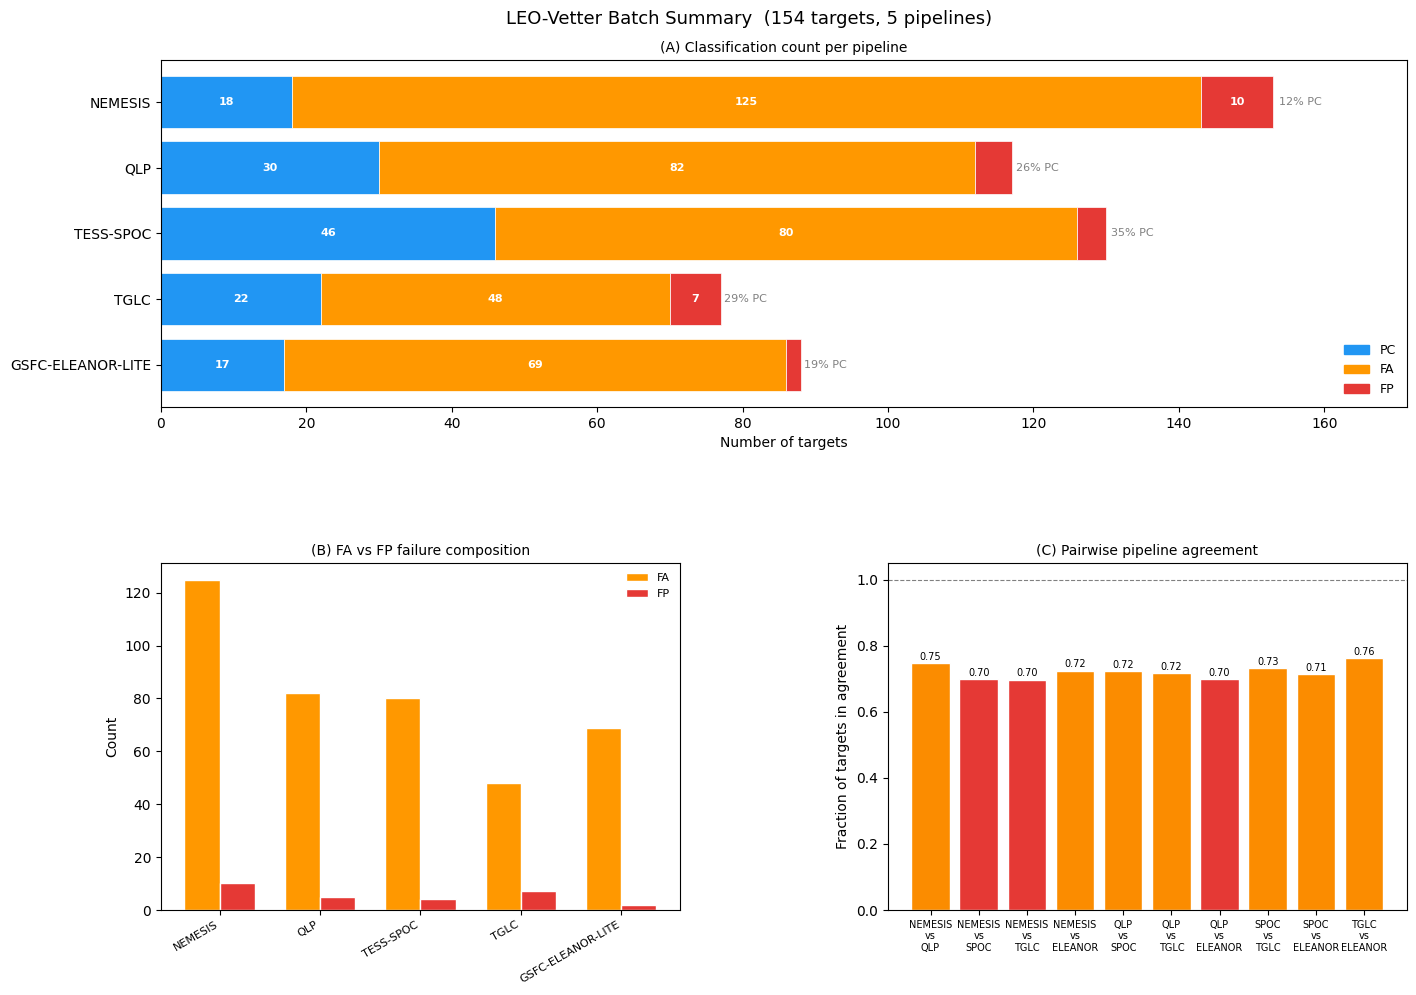

Saved: /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/batch_results/saved_results/figures/population_summary_agnostic.png


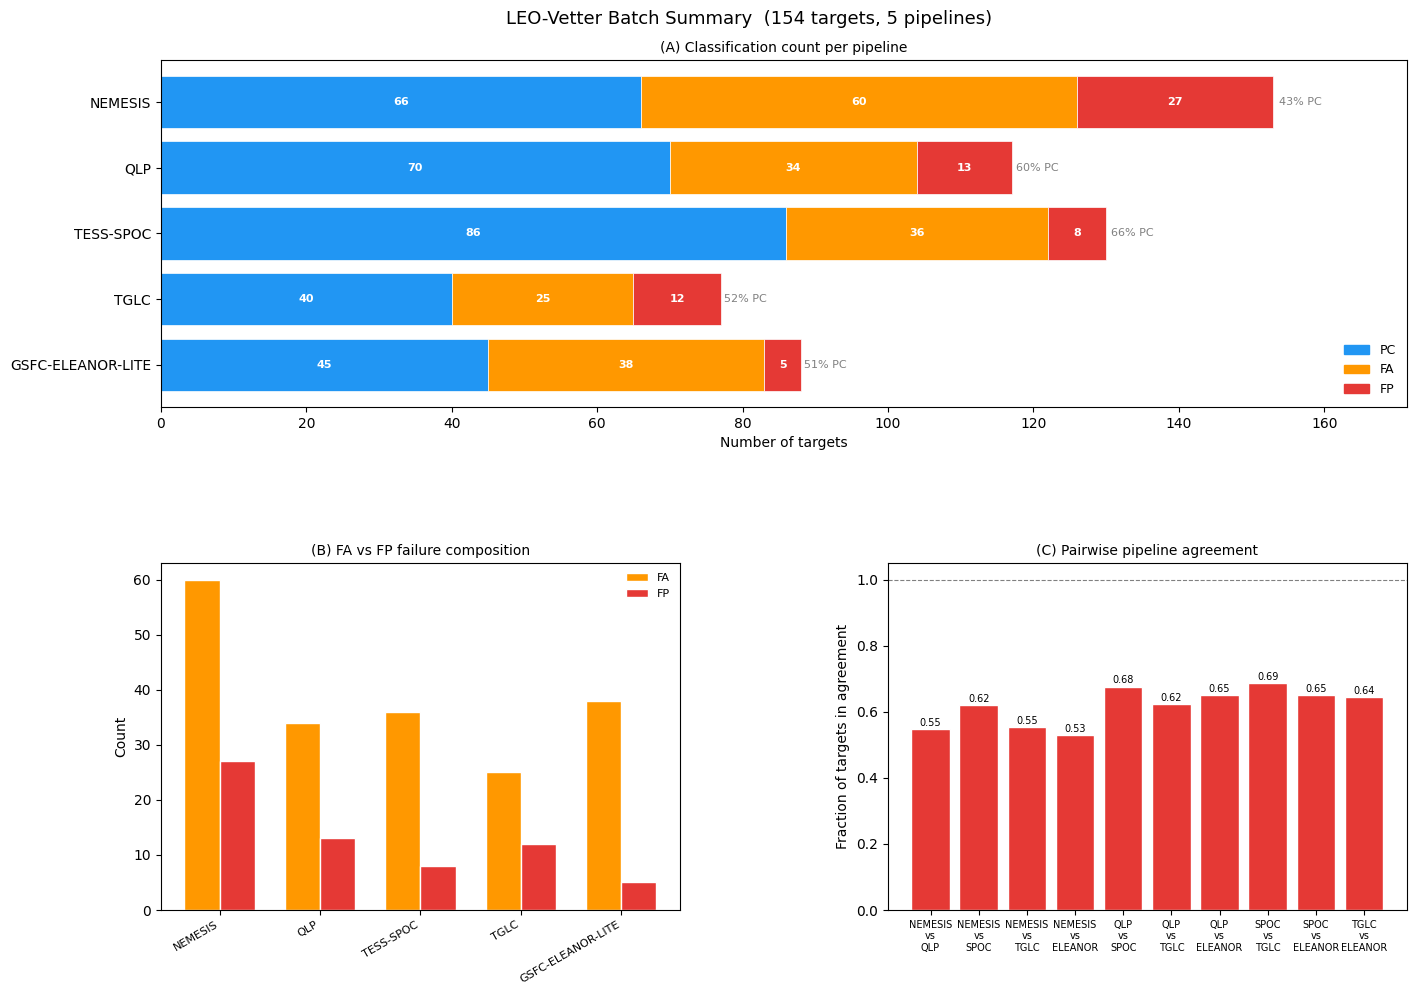


Targets where consensus classification changed: 72
pipeline  consensus NEMESIS  QLP TESS-SPOC TGLC GSFC-ELEANOR-LITE
ID                                                               
111778581        FA      FA  NaN       NaN   FA                FA
126606859       FA*      FA   FA        PC  NaN               NaN
141202786        FA      FA  NaN       NaN  NaN               NaN
141527579       FP*      FP   PC        PC   FP                FA
142748283        FA      FA   FA        FA  NaN               NaN
150428135       FA*      FA   PC        PC   FP                FA
151825527       FA*      FA   PC        FA   FP                PC
155867025        FA      FA   FA       NaN  NaN               NaN
157769780        FA      FA   FA        FA  NaN               NaN
160162137       FA*      FA  NaN        PC  NaN               NaN
161032923        FA      FA   FA        FA  NaN                FA
166648874        FA      FA   FA        FA  NaN               NaN
168751223       FA*     


Saved enriched catalog -> /Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/batch_results/saved_results/leovetter_batch_catalog_classified.parquet
Columns added: classification, classification_agnostic, classification_contested, LEOVetter_flag_any_FA_agnostic, LEOVetter_flag_any_FP_agnostic


In [112]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from leo_vetter.thresholds import _default_thresholds

from leovetter_batch_analysis import (
    compile_batch_leovetter_catalog,
    add_per_test_flags,
    derive_classification,
    plot_population_summary,
    plot_flag_rate_heatmap,
    classification_agreement_table,
    derive_detrending_agnostic_classification
)
# derive_detrending_agnostic_classification lives in the same file once added
# from leovetter_batch_analysis import derive_detrending_agnostic_classification

RESULTS_ROOT = "/Users/daxfeliz/Desktop/Mentoring/Madeline/project2026/main/HLSP/batch_results/saved_results/"
SAVEDIR      = os.path.join(RESULTS_ROOT, "figures")
os.makedirs(SAVEDIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# Step 1. Compile catalog
# ─────────────────────────────────────────────────────────────────────────────
# cat = compile_batch_leovetter_catalog(RESULTS_ROOT)
cat = compile_batch_leovetter_catalog_filtered(results_root=RESULTS_ROOT, 
                                               filtered_df=filtered_df)

print(f"Catalog: {len(cat)} rows, {cat['ID'].nunique()} targets, "
      f"{cat['pipeline'].nunique()} pipelines")
# e.g. "Catalog: 2000 rows, 400 targets, 5 pipelines"

# ─────────────────────────────────────────────────────────────────────────────
# Step 2. Derive per-test boolean flags using real thresholds
# CHI threshold left at canonical 7.8 here; adjust after validating against
# confirmed KPs/CPs in your sample.
# ─────────────────────────────────────────────────────────────────────────────
cat = add_per_test_flags(cat, thresholds=_default_thresholds, chi_threshold=None)

# ─────────────────────────────────────────────────────────────────────────────
# Step 3. Full classification (all 17 tests)
# ─────────────────────────────────────────────────────────────────────────────
cat = derive_classification(cat)

print("\nFull classification counts (all pipelines combined):")
print(cat["classification"].value_counts())
# e.g.  PC: 1400  FA: 450  FP: 150

print("\nFull classification counts per pipeline:")
print(cat.groupby("pipeline")["classification"].value_counts().unstack(fill_value=0))

# ─────────────────────────────────────────────────────────────────────────────
# Step 4. Detrending-agnostic classification (drops chi, sinusoidal, non_unique)
# ─────────────────────────────────────────────────────────────────────────────
cat = derive_detrending_agnostic_classification(
    cat,
    excluded_tests=("chi", "sinusoidal", "non_unique", "invalid_transits","bad_fit","weak"),
)
# Printed output shows:
#   - which tests were excluded
#   - total fraction of rows that changed classification
#   - per-pipeline breakdown of contested rows
#   - transition matrix (e.g. FA -> PC, FA -> FP)

# ─────────────────────────────────────────────────────────────────────────────
# Step 5. Inspect what changed
# ─────────────────────────────────────────────────────────────────────────────

# 5a. Side-by-side classification counts: full vs agnostic
print("\nAgnostic classification counts (all pipelines combined):")
print(cat["classification_agnostic"].value_counts())

print("\nFull vs agnostic -- targets that changed:")
changed = cat[cat["classification_contested"]]
print(f"  {len(changed)} rows changed classification "
      f"({100*len(changed)/len(cat):.1f}% of catalog)")

# 5b. The scientifically interesting subset: targets that flip FA -> PC.
# These were classified as FA only because of detrending-sensitive tests,
# not because of a genuine signal quality problem. Highest manual inspection
# priority.
fa_to_pc = cat[
    (cat["classification"] == "FA") &
    (cat["classification_agnostic"] == "PC")
].copy()
print(f"\n  FA -> PC (detrending-driven FAs): {len(fa_to_pc)} rows")
print(fa_to_pc[["ID", "pipeline", "classification", "classification_agnostic",
                 "LEOVetter_flag_chi", "LEOVetter_flag_sinusoidal",
                 "LEOVetter_flag_non_unique"]].to_string(index=False))

# 5c. Targets that flip PC -> FA. These were passing with full tests but fail
# when detrending-sensitive tests are dropped -- less common, but indicates
# the signal only passes because chi/sinusoidal/non_unique are NOT firing
# (i.e., a weak signal rescued by lenient detrending-sensitive tests).
# This direction of change is rare; flag for awareness.
pc_to_fa = cat[
    (cat["classification"] == "PC") &
    (cat["classification_agnostic"] == "FA")
].copy()
if len(pc_to_fa) > 0:
    print(f"\n  PC -> FA (check these): {len(pc_to_fa)} rows")
    print(pc_to_fa[["ID", "pipeline", "classification",
                     "classification_agnostic"]].to_string(index=False))

# 5d. Per-pipeline: how many targets are contested?
contested_by_pipe = (
    cat.groupby("pipeline")["classification_contested"]
    .agg(n_contested="sum", n_total="count")
    .assign(frac_contested=lambda d: d["n_contested"] / d["n_total"])
)
print("\nContested fraction by pipeline:")
print(contested_by_pipe.to_string())
# Expect TGLC and GSFC-ELEANOR-LITE to have the highest contested fractions
# since chi fires more on those pipelines due to rolling-MAD error estimation.

# ─────────────────────────────────────────────────────────────────────────────
# Step 6. Unique contested targets (collapsed across pipelines)
# A target is "pipeline-contested" if its agnostic classification differs
# from its full classification in at least one pipeline.
# ─────────────────────────────────────────────────────────────────────────────
contested_targets = (
    cat.groupby("ID")["classification_contested"]
    .any()
    .reset_index()
    .rename(columns={"classification_contested": "any_pipeline_contested"})
)
n_contested_targets = contested_targets["any_pipeline_contested"].sum()
print(f"\nTargets contested in at least one pipeline: "
      f"{n_contested_targets} / {cat['ID'].nunique()}")

# ─────────────────────────────────────────────────────────────────────────────
# Step 7. Visualize -- flag rate heatmap for both classification modes
# ─────────────────────────────────────────────────────────────────────────────

# Full classification flag heatmap (all tests)
fig_full = plot_flag_rate_heatmap(
    cat,
    savepath=os.path.join(SAVEDIR, "flag_rate_heatmap_full.png"),
)
fig_full.suptitle("Flag rates -- all tests", fontsize=11)
plt.show()

# Agnostic classification flag heatmap.
# To show only the retained tests, temporarily mask the excluded flag columns
# to False so the heatmap reflects what goes into the agnostic classification.
EXCLUDED = ("chi", "sinusoidal", "non_unique")
cat_agnostic_view = cat.copy()
for t_name in EXCLUDED:
    col_name = f"LEOVetter_flag_{t_name}"
    if col_name in cat_agnostic_view.columns:
        cat_agnostic_view[col_name] = False

fig_agnostic = plot_flag_rate_heatmap(
    cat_agnostic_view,
    savepath=os.path.join(SAVEDIR, "flag_rate_heatmap_agnostic.png"),
)
fig_agnostic.suptitle(
    f"Flag rates -- agnostic (excluding: {', '.join(EXCLUDED)})", fontsize=11
)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Step 8. Population summary for both classification modes
# ─────────────────────────────────────────────────────────────────────────────

# Full
fig_pop_full = plot_population_summary(
    cat,
    class_col="classification",
    savepath=os.path.join(SAVEDIR, "population_summary_full.png"),
)
plt.show()

# Agnostic -- pass classification_agnostic as the class column
fig_pop_agnostic = plot_population_summary(
    cat,
    class_col="classification_agnostic",
    savepath=os.path.join(SAVEDIR, "population_summary_agnostic.png"),
)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Step 9. Agreement table -- shows per-target per-pipeline classifications
# Run for both modes to compare which targets are now consistently PC.
# ─────────────────────────────────────────────────────────────────────────────
tbl_full = classification_agreement_table(cat, class_col="classification")
tbl_agnostic = classification_agreement_table(cat, class_col="classification_agnostic")

# Targets where consensus changed between full and agnostic
consensus_changed = tbl_full.index[
    tbl_full["consensus"].str.rstrip("*") !=
    tbl_agnostic["consensus"].str.rstrip("*")
]
print(f"\nTargets where consensus classification changed: {len(consensus_changed)}")
if len(consensus_changed) > 0:
    print(tbl_full.loc[consensus_changed, ["consensus"] +
          [p for p in ["NEMESIS","QLP","TESS-SPOC","TGLC","GSFC-ELEANOR-LITE"]
           if p in tbl_full.columns]])
    print("\n-- agnostic --")
    print(tbl_agnostic.loc[consensus_changed, ["consensus"] +
          [p for p in ["NEMESIS","QLP","TESS-SPOC","TGLC","GSFC-ELEANOR-LITE"]
           if p in tbl_agnostic.columns]])

# ─────────────────────────────────────────────────────────────────────────────
# Step 10. Save the enriched catalog with both classification columns
# ─────────────────────────────────────────────────────────────────────────────
out_path = os.path.join(RESULTS_ROOT, "leovetter_batch_catalog_classified.parquet")
cat.to_parquet(out_path, index=False)
print(f"\nSaved enriched catalog -> {out_path}")
print(f"Columns added: classification, classification_agnostic, "
      f"classification_contested, LEOVetter_flag_any_FA_agnostic, "
      f"LEOVetter_flag_any_FP_agnostic")

In [113]:
Pipelines= ['QLP', 'TESS-SPOC', 'TGLC', 'GSFC-ELEANOR-LITE'] + ['NEMESIS']
Pipelines

['QLP', 'TESS-SPOC', 'TGLC', 'GSFC-ELEANOR-LITE', 'NEMESIS']

In [114]:
pipelines= ['QLP', 'TESS-SPOC', 'TGLC', 'GSFC-ELEANOR-LITE'] + ['NEMESIS']

for p in pipelines+ ['NEMESIS']:
    count = (cat["pipeline"] == p).sum()
    print(f"{p} rows: {count}")
    print(f"Targets with {p}: {cat[cat['pipeline']==p]['ID'].nunique()}")
    print(f"Total targets: {cat['ID'].nunique()}")
    print(' ')

QLP rows: 117
Targets with QLP: 116
Total targets: 154
 
TESS-SPOC rows: 130
Targets with TESS-SPOC: 129
Total targets: 154
 
TGLC rows: 77
Targets with TGLC: 76
Total targets: 154
 
GSFC-ELEANOR-LITE rows: 88
Targets with GSFC-ELEANOR-LITE: 87
Total targets: 154
 
NEMESIS rows: 153
Targets with NEMESIS: 153
Total targets: 154
 
NEMESIS rows: 153
Targets with NEMESIS: 153
Total targets: 154
 


In [115]:
import os
import glob
from pathlib import Path

RESULTS_SAVEPATH = os.path.join(RESULTS_ROOT, "saved_results")

# ── Step 1: which targets are missing NEMESIS in the catalog ─────────────────
all_targets     = set(cat["ID"].astype(str).unique())
nemesis_targets = set(cat[cat["pipeline"] == "NEMESIS"]["ID"].astype(str).unique())
missing_nemesis = sorted(all_targets - nemesis_targets)

print(f"Targets missing NEMESIS: {len(missing_nemesis)} / {len(all_targets)}")

# ── Step 2: for each missing target, check what is on disk ───────────────────
rows = []
for tic_id in missing_nemesis:
    # Find any TIC{id}_S* output directory
    candidates = sorted(glob.glob(
        os.path.join(RESULTS_SAVEPATH, f"TIC{tic_id}_S*")
    ))

    if not candidates:
        rows.append({
            "tic_id":          tic_id,
            "output_dir":      None,
            "nemesis_parquet": False,
            "diagnosis":       "NO_OUTPUT_DIR -- target never had a full run",
        })
        continue

    for cand in candidates:
        stag           = os.path.basename(cand).replace(f"TIC{tic_id}_", "", 1)
        nemesis_path   = os.path.join(cand, "NEMESIS_concat_standardized_masked.parquet")
        has_nemesis    = os.path.isfile(nemesis_path)
        catalog_path   = os.path.join(cand, f"TIC{tic_id}_{stag}_leovetter_catalog.parquet")
        has_catalog    = os.path.isfile(catalog_path)

        # Check what pipelines are in the existing catalog parquet
        pipelines_in_catalog = []
        if has_catalog:
            try:
                tmp = pd.read_parquet(catalog_path)
                pipelines_in_catalog = tmp["pipeline"].tolist() if "pipeline" in tmp.columns else []
            except Exception:
                pipelines_in_catalog = ["READ_ERROR"]

        if not has_nemesis:
            diagnosis = "NEMESIS_PARQUET_MISSING -- force_releovetter cache load failed for this sector_tag"
        elif "NEMESIS" not in pipelines_in_catalog:
            diagnosis = "NEMESIS_NOT_IN_CATALOG -- parquet exists but NEMESIS absent from catalog (Apply_LEOVetter failed)"
        else:
            diagnosis = "OK -- NEMESIS present (should not be in missing list)"

        rows.append({
            "tic_id":               tic_id,
            "output_dir":           stag,
            "nemesis_parquet":      has_nemesis,
            "pipelines_in_catalog": str(pipelines_in_catalog),
            "diagnosis":            diagnosis,
        })

diag_df = pd.DataFrame(rows)
print("\nDiagnosis breakdown:")
print(diag_df["diagnosis"].value_counts().to_string())
print()
print(diag_df[["tic_id", "output_dir", "nemesis_parquet", "diagnosis"]].to_string(index=False))

# ── Step 3: targets that can be fixed with force_releovetter ─────────────────
# These have the NEMESIS parquet on disk but Apply_LEOVetter failed
fixable = diag_df[
    diag_df["nemesis_parquet"] == True
]["tic_id"].tolist()

# Targets that need a full rerun (no NEMESIS parquet on disk at all)
needs_full_rerun = diag_df[
    diag_df["nemesis_parquet"] == False
]["tic_id"].tolist()

print(f"\nTargets fixable with force_releovetter (NEMESIS parquet exists): {len(fixable)}")
print(f"Targets needing full rerun (no NEMESIS parquet):                  {len(needs_full_rerun)}")


Targets missing NEMESIS: 1 / 154

Diagnosis breakdown:
diagnosis
NO_OUTPUT_DIR -- target never had a full run    1

  tic_id output_dir  nemesis_parquet                                    diagnosis
86263325       None            False NO_OUTPUT_DIR -- target never had a full run

Targets fixable with force_releovetter (NEMESIS parquet exists): 0
Targets needing full rerun (no NEMESIS parquet):                  1


# Below is a piece of code meant to fix missing LEO-Vetter .parquet files that exist but are not being read in properly

# ONLY run this once!

In [116]:
from Full_HLSP_and_NEMESIS_Comparison_pipeline import find_cached_sector_tag
def rebuild_leovetter_catalog_from_parquets(
    results_savepath: str,
    tic_id: Union[int, str],
    sector_tag: str,
    target: Union[pd.Series, pd.DataFrame],
    pipelines: List[str],
) -> Optional[pd.DataFrame]:
    """
    Rebuild the per-target leovetter_catalog.parquet by reading each
    pipeline's {PIPELINE}_leovetter_metrics.parquet directly from disk,
    rather than relying on leo_vetter_vetted being populated in memory.

    This fixes the case where NEMESIS (or any pipeline) has a valid
    leovetter_metrics.parquet on disk but was absent from the in-memory
    combined_results when _persist_leovetter_catalog was called -- which
    causes NEMESIS to be silently excluded from the catalog parquet.

    Parameters
    ----------
    results_savepath : str
        Path to saved_results root.
    tic_id : int or str
    sector_tag : str
        e.g. "S0002"
    target : pd.Series or pd.DataFrame
        Target metadata row (used to fill shared columns).
    pipelines : list of str
        All pipeline names to attempt, including "NEMESIS".

    Returns
    -------
    pd.DataFrame or None
        Rebuilt catalog, or None if no metrics parquets found.
    """
    outdir = os.path.join(results_savepath, f"TIC{tic_id}_{sector_tag}")
    if not os.path.isdir(outdir):
        return None

    if isinstance(target, pd.DataFrame):
        target_df = target.reset_index(drop=True)
    else:
        target_df = target.to_frame().T.reset_index(drop=True)

    rows = []
    for p in pipelines:
        metrics_path = os.path.join(outdir, f"{p}_leovetter_metrics.parquet")
        if not os.path.isfile(metrics_path):
            continue
        try:
            metrics = pd.read_parquet(metrics_path)
            if metrics.empty:
                continue
            # metrics parquet has raw column names; add LEOVetter_ prefix
            # only if not already prefixed (handles both old and new format)
            if not any(c.startswith("LEOVetter_") for c in metrics.columns):
                metrics = metrics.add_prefix("LEOVetter_")
            row = pd.concat(
                [target_df.reset_index(drop=True),
                 metrics.reset_index(drop=True)],
                axis=1,
            )
            row.insert(0, "pipeline", p)
            rows.append(row)
        except Exception as exc:
            print(f"[rebuild_catalog] WARNING: could not read {p} metrics: {exc}")

    if not rows:
        return None

    return pd.concat(rows, ignore_index=True)


def fix_missing_nemesis_catalogs(
    filtered_df: pd.DataFrame,
    results_savepath: str,
    pipelines: List[str],
) -> None:
    """
    For every target in filtered_df whose leovetter_catalog.parquet is
    missing NEMESIS, rebuild the catalog from the per-pipeline metrics
    parquets on disk and overwrite the catalog file.

    Run this once after identifying missing NEMESIS rows. No photometry
    reruns needed -- only the catalog parquet is rewritten.

    Parameters
    ----------
    filtered_df : pd.DataFrame
        Target list. Must contain 'TIC ID'.
    results_savepath : str
        Direct path to saved_results directory (i.e. the directory that
        contains the TIC{id}_S* subdirectories). Do NOT pass the parent
        batch_results root -- pass the saved_results path directly.
        Example: "/path/to/batch_results/saved_results/"
    pipelines : list of str
        All pipeline names including "NEMESIS".
    """
    all_pipelines    = pipelines + (["NEMESIS"] if "NEMESIS" not in pipelines else [])

    fixed    = 0
    skipped  = 0
    no_dir   = 0

    for _, target in filtered_df.iterrows():
        tic_id = int(target["TIC ID"])

        # Find the output directory
        stag = find_cached_sector_tag(tic_id, results_savepath)
        if stag is None:
            no_dir += 1
            continue

        outdir       = os.path.join(results_savepath, f"TIC{tic_id}_{stag}")
        catalog_path = os.path.join(outdir, f"TIC{tic_id}_{stag}_leovetter_catalog.parquet")

        # Check if NEMESIS is already in the catalog
        if os.path.isfile(catalog_path):
            try:
                existing = pd.read_parquet(catalog_path)
                if "NEMESIS" in existing.get("pipeline", pd.Series()).tolist():
                    skipped += 1
                    continue  # already has NEMESIS, nothing to do
            except Exception:
                pass  # corrupt parquet -- rebuild it

        # Rebuild from per-pipeline metrics parquets
        rebuilt = rebuild_leovetter_catalog_from_parquets(
            results_savepath=results_savepath,
            tic_id=tic_id,
            sector_tag=stag,
            target=target,
            pipelines=all_pipelines,
        )

        if rebuilt is None or rebuilt.empty:
            print(f"[fix_catalogs] TIC {tic_id}: no metrics parquets found, skipping")
            skipped += 1
            continue

        pipelines_in_rebuilt = rebuilt["pipeline"].tolist()
        rebuilt.to_parquet(catalog_path, index=False)
        print(f"[fix_catalogs] TIC {tic_id} ({stag}): rebuilt catalog "
              f"with pipelines {pipelines_in_rebuilt}")
        fixed += 1

    print(f"\n[fix_catalogs] Done. fixed={fixed}, already_ok={skipped}, no_dir={no_dir}")




# ONLY run this once!

In [117]:
# ─────────────────────────────────────────────────────────────────────────────
# Usage
# ─────────────────────────────────────────────────────────────────────────────
#
# Run this ONCE to repair all catalog parquets that are missing NEMESIS.
# Then re-run compile_batch_leovetter_catalog_filtered as normal.
#
fix_missing_nemesis_catalogs(
    filtered_df=filtered_df,
    results_savepath=RESULTS_ROOT,
    pipelines=pipelines,   # ["QLP", "TESS-SPOC", "TGLC", "GSFC-ELEANOR-LITE"]
)

[fix_catalogs] TIC 86263325 (S0022): rebuilt catalog with pipelines ['QLP']
[fix_catalogs] TIC 313889049: no metrics parquets found, skipping
[fix_catalogs] TIC 22233480: no metrics parquets found, skipping
[fix_catalogs] TIC 39926974: no metrics parquets found, skipping
[fix_catalogs] TIC 384888319: no metrics parquets found, skipping
[fix_catalogs] TIC 381897917: no metrics parquets found, skipping
[fix_catalogs] TIC 103605399: no metrics parquets found, skipping
[fix_catalogs] TIC 336961891: no metrics parquets found, skipping
[fix_catalogs] TIC 203214081: no metrics parquets found, skipping
[fix_catalogs] TIC 19028197: no metrics parquets found, skipping
[fix_catalogs] TIC 150096001: no metrics parquets found, skipping
[fix_catalogs] TIC 434226736: no metrics parquets found, skipping
[fix_catalogs] TIC 165202476: no metrics parquets found, skipping
[fix_catalogs] TIC 143032776: no metrics parquets found, skipping
[fix_catalogs] TIC 324609476: no metrics parquets found, skipping
[fi